IMDB Movie Review Sentiment Classification using LSTM

Codes adapted from the book "Deep Learning with Python" (2018) by Francois Chollet, page 198-201


# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-4e2c5d39-5623-15b7-c496-71b271e04dc9)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


In [3]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
#keras.utils.set_random_seed(1234)

# 2. Prepare the IMDB dataset

## 2.1 Load the dataset

- About the dataset https://keras.io/datasets/#imdb-movie-reviews-sentiment-classification

  > This is a dataset of 25,000 movies reviews from IMDB, labeled by sentiment (positive/negative). Reviews have been preprocessed, and each review is encoded as a list of word indexes (integers). For convenience, words are indexed by overall frequency in the dataset, so that for instance the integer "3" encodes the 3rd most frequent word in the data. This allows for quick filtering operations such as: "only consider the top 10,000 most common words, but eliminate the top 20 most common words".

  > As a convention, "0" does not stand for a specific word, but instead is used to encode any unknown word.

- Read about parameters regarding ` keras.datasets.imdb.load_data()` in https://keras.io/api/datasets/imdb/

In [4]:
# Codes in this cell are (mostly) from https://keras.io/api/datasets/imdb/

# Use the default parameters to keras.datasets.imdb.load_data()
# - Reserve the indices of 0 for padding, 1 for start, and 2 for OOV
# - Start indexing the word in IMDB dataset with 3 and so on
start_char = 1
oov_char = 2        # Out-of-vocabulary (OOV) character
index_from = 3
vocab_size = 10000  # (Optional) Consider only 10,000 top most frequent words

# Retrieve the training sequences
(x_train, y_train) , (x_test, y_test) = keras.datasets.imdb.load_data(
                                                    start_char=start_char,
                                                    oov_char=oov_char,
                                                    index_from=index_from,
                                                    num_words=vocab_size )

# Retrieve the word index file mapping words to indices
word_index = keras.datasets.imdb.get_word_index()

# Reverse the word index to obtain a dict mapping indices to words
# And add `index_from` to indices to sync with `x_train`
inverted_word_index = dict( (i + index_from, word) for (word, i) in word_index.items() )

# Update `inverted_word_index` to include `start_char` and `oov_char`
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Inspect data from the above cell
vars_dict = dict( x_train=x_train, y_train=y_train,
                  x_test=x_test, y_test=y_test,
                  word_index=word_index, inverted_word_index=inverted_word_index )
for (var_name, var) in vars_dict.items():
  if hasattr(var, "shape"):
    print(f"{var_name}: type={type(var)} , shape={var.shape} , dtype={var.dtype}")
  elif hasattr(var, "__len__"):
    print(f"{var_name}: type={type(var)} , len={len(var)}")

x_train: type=<class 'numpy.ndarray'> , shape=(25000,) , dtype=object
y_train: type=<class 'numpy.ndarray'> , shape=(25000,) , dtype=int64
x_test: type=<class 'numpy.ndarray'> , shape=(25000,) , dtype=object
y_test: type=<class 'numpy.ndarray'> , shape=(25000,) , dtype=int64
word_index: type=<class 'dict'> , len=88584
inverted_word_index: type=<class 'dict'> , len=88586


In [6]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [7]:
inverted_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

- Inspect the loaded dataset

In [8]:
# Show the raw data where words are all encoded as integers

# Remind that for x, 0 is padding, 1 is start, and 2 is unknown (OOV)
print( f"Training set: {x_train.shape=} , {y_train.shape=}" )
print( f"Testing set: {x_test.shape=} , {y_test.shape=}" )

# Preview the first 'n' data in the train set
n = 5
for i in range(n):
    print( f'\n====== Train review {i} ======' )

    # x_train[i] is a list of integers
    print( f'x_train: len={len(x_train[i])} , min_index={min(x_train[i])} , max_index={max(x_train[i])})' )
    print( f'>> {x_train[i]}\n' )

    # y_train[i] is a rating value (0=negative, 1=positive)
    print( f'y_train: {y_train[i]}' )

Training set: x_train.shape=(25000,) , y_train.shape=(25000,)
Testing set: x_test.shape=(25000,) , y_test.shape=(25000,)

====== Train review 0 ======
x_train: len=218 , min_index=1 , max_index=7486)
>> [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144

In [9]:
# Decode the data to a readable format using the two dicts ('word_index' and 'inverted_word_index')
# Show the decoded data where words are properly printed in string

# Remind that for x, 0=pad, 1=start, and 2=unknown (OOV)
print( f"Training set: {x_train.shape=} , {y_train.shape=}" )
print( f"Testing set: {x_test.shape=} , {y_test.shape=}" )

# Preview the first 'n' data in the train set
n = 5
for i in range(n):
    print( f'\n====== Train review {i} ======' )

    # x_train[i] is a list of integers
    print( f'x_train: len={len(x_train[i])} , min_index={min(x_train[i])} , max_index={max(x_train[i])})' )
    print( f'>> {" ".join(inverted_word_index[j] for j in x_train[i])}\n' )

    # y_train[i] is a rating value (0=negative, 1=positive)
    print( f'y_train: {y_train[i]}' )

Training set: x_train.shape=(25000,) , y_train.shape=(25000,)
Testing set: x_test.shape=(25000,) , y_test.shape=(25000,)

====== Train review 0 ======
x_train: len=218 , min_index=1 , max_index=7486)
>> [START] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [OOV] is an amazing actor and now the same being director [OOV] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [OOV] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [OOV] to the two little boy's that played the [OOV] of norman and paul they were just brilliant

## 2.2 Pad or crop each sentence

Make the length of all reviews the same
- If it is shorter than 500, pad it.
- If it is longer than 500, cut it.

In [10]:
MAX_LENGTH = 500
x_train_pad = keras.preprocessing.sequence.pad_sequences( x_train, maxlen=MAX_LENGTH )
x_test_pad = keras.preprocessing.sequence.pad_sequences( x_test, maxlen=MAX_LENGTH )

# Inspect the IMDB dataset (after padding)
print( f"Training set: x_train_pad.shape={x_train_pad.shape} , x_train_pad.dtype={x_train_pad.dtype} , y_train.shape={y_train.shape}" )
print( f"Testing set: x_test_pad.shape={x_test_pad.shape} , x_test_pad.dtype={x_test_pad.dtype} , y_test.shape={y_test.shape}" )
n = 5
for i in range(n):
    print( f'\n====== Train review {i} ======' )

    # x_train_pad[i] is a list of integers
    print( f'x_train_pad: len={len(x_train_pad[i])} , min_index={min(x_train_pad[i])} , max_index={max(x_train_pad[i])})' )
    print( f'>> {x_train_pad[i]}\n' )

    # y_train[i] is a rating value (0=negative, 1=positive)
    print( f'y_train: {y_train[i]}' )

Training set: x_train_pad.shape=(25000, 500) , x_train_pad.dtype=int32 , y_train.shape=(25000,)
Testing set: x_test_pad.shape=(25000, 500) , x_test_pad.dtype=int32 , y_test.shape=(25000,)

====== Train review 0 ======
x_train_pad: len=500 , min_index=0 , max_index=7486)
>> [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0 

# 3. Create an LSTM model

- Convert one positive integer index (representing one word) to a (dense) 64D floating-point vector
  - Use `keras.layers.Embedding()` to learn appropriate embedding through backpropagation <u>**OR**</u>
  - Use the pre-trained word embedding as in https://keras.io/examples/nlp/pretrained_word_embeddings/

In [11]:
model = keras.models.Sequential()

# Input layer
model.add( keras.Input(shape=(None,), name='input') )

# The embedding layer turns positive integers (indexes) into fixed-size dense vectors.
# - For example, from [[4], [20]] to [[0.25, 0.1], [0.6, -0.2]]
# - Can only be used on positive integer inputs of a fixed range
# - Can only be used as the first layer in a model
model.add( keras.layers.Embedding( input_dim=vocab_size+index_from, # Size of the vocabulary Size of the vocabulary (i.e. maximum integer index + 1)
                                   output_dim=64 )    # Dimension of the dense embedding
         )

# Two layers of LSTM
model.add( keras.layers.LSTM(units=32, return_sequences=True) )
model.add( keras.layers.LSTM(units=32) )   # This last layer only returns the last-time-step output

# One dense layer for binary classification
model.add( keras.layers.Dense(1,activation='sigmoid') )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       640,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 32)       │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,961 (2.52 MB)

 Trainable params: 660,961 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and train the model

In [12]:
model.compile( optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'] )

In [13]:
hist = model.fit( x_train_pad, y_train, epochs=10, batch_size=128, validation_split=0.2 )

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - acc: 0.5582 - loss: 0.6618 - val_acc: 0.7656 - val_loss: 0.4806
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - acc: 0.8437 - loss: 0.3703 - val_acc: 0.8116 - val_loss: 0.4089
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - acc: 0.8954 - loss: 0.2697 - val_acc: 0.8744 - val_loss: 0.3260
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - acc: 0.9148 - loss: 0.2241 - val_acc: 0.8508 - val_loss: 0.3496
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - acc: 0.9275 - loss: 0.1930 - val_acc: 0.8402 - val_loss: 0.3594
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - acc: 0.9391 - loss: 0.1702 - val_acc: 0.8596 - val_loss: 0.3676
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - acc: 0.9500 - loss: 0.1390 - val_acc: 0.8702 - val_loss: 0.3332
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - acc: 0.9583 - loss: 0.1203 - val_acc: 0.8680 - val_loss: 0.3251
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/

In [14]:
hist.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

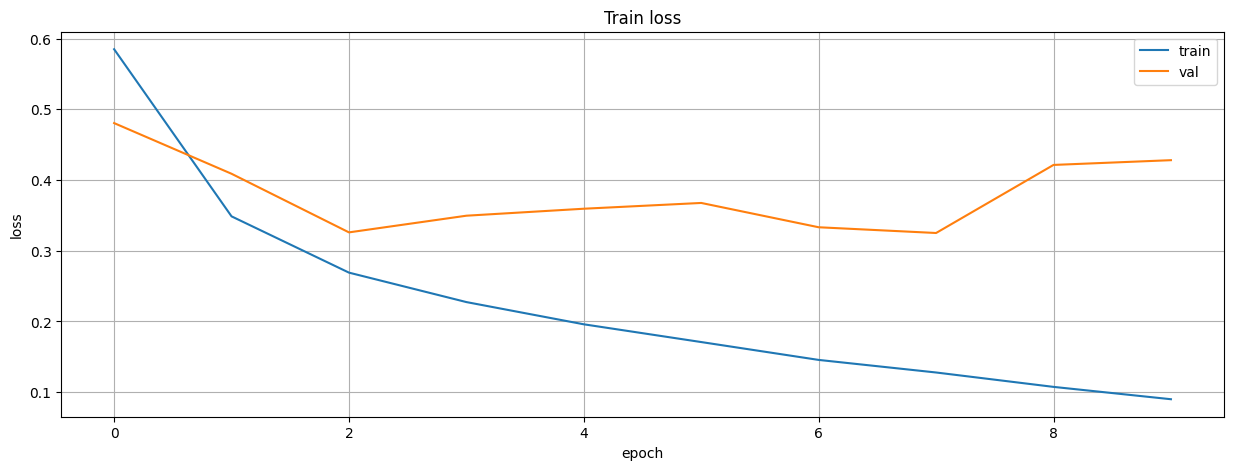

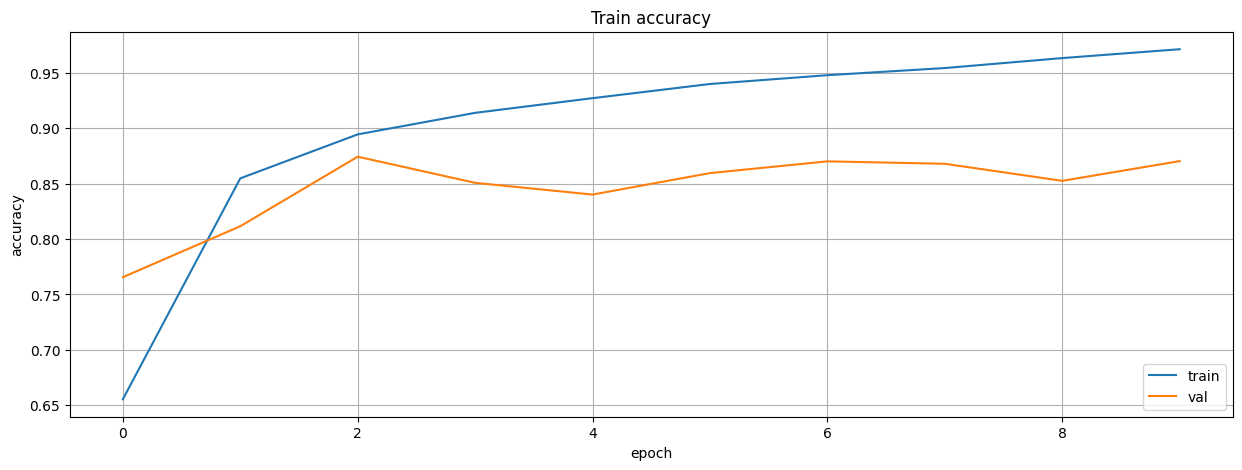

In [15]:
# Summarize history for loss
plt.figure(figsize=(15,5))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Train loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Summarize history for accuracy
plt.figure(figsize=(15,5))
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.title('Train accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.grid()
plt.show()

# 5. Evaluate the model

In [16]:
score = model.evaluate( x_test_pad, y_test, verbose=1, return_dict=True )

print( "Test results (model from the last epoch):", score )

782/782 ━━━━━━━━━━━━━━━━━━━━ 534s 683ms/step - acc: 0.8592 - loss: 0.4624
Test results (model from the last epoch): {'acc': 0.8582000136375427, 'loss': 0.4653330445289612}


# 6. Inference

In [17]:
# Inference on one test data

# Prepare data
# Convert x_test[i] from a list of integers to a 2D numpy array of shape (1,n_words)
i = 0
sample = np.array ( [ x_test[i] ], dtype=np.int32 )
print(f"{type(sample)=} , {sample.shape=} , {sample.dtype=}")

# Predict
y_pred = model.predict( sample, verbose=0 )
print(f"{type(y_pred)=} , {y_pred.shape=} , {y_pred.dtype=}\n")

# Show the result
print( f'x_test: len={len(x_test[i])} , min_index={min(x_test[i])} , max_index={max(x_test[i])})' )
print( f'>> {" ".join(inverted_word_index[j] for j in x_test[i])}\n' )
print( f'y_test: {y_test[i]}' )
print( f'y_pred: {y_pred.squeeze():.4f}' )

type(sample)=<class 'numpy.ndarray'> , sample.shape=(1, 68) , sample.dtype=dtype('int32')
type(y_pred)=<class 'numpy.ndarray'> , y_pred.shape=(1, 1) , y_pred.dtype=dtype('float32')

x_test: len=68 , min_index=1 , max_index=7944)
>> [START] please give this one a miss br br [OOV] [OOV] and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite [OOV] so all you madison fans give this a miss

y_test: 0
y_pred: 0.1135


In [18]:
# Inference on the first 'n' data in the test set

# Prepare data
# To send a batch of reviews (shape = (bs,seq_length)), each review must be padded to the same length
n = 20
longest = max( [ len(x) for x in x_test[:n] ] )
samples = keras.preprocessing.sequence.pad_sequences( x_test[:n], maxlen=longest )
print(f"{type(samples)=} , {samples.shape=} , {samples.dtype=}")

# Predict
y_preds = model.predict( samples, verbose=0 )
print(f"{type(y_preds)=} , {y_preds.shape=} , {y_preds.dtype=}\n")

# Show results
for i in range(n):
    print( f'\n====== Test review {i} ======' )

    # x is a list of integers
    print( f'x_test: len={len(x_test[i])} , min_index={min(x_test[i])} , max_index={max(x_test[i])})' )
    print( f'>> {" ".join(inverted_word_index[j] for j in x_test[i])}\n' )

    # y is a rating value (0=negative, 1=positive)
    print( f'y_test: {y_test[i]}' )
    print( f'y_pred: {y_preds[i].squeeze():.4f}' )

type(samples)=<class 'numpy.ndarray'> , samples.shape=(20, 761) , samples.dtype=dtype('int32')
type(y_preds)=<class 'numpy.ndarray'> , y_preds.shape=(20, 1) , y_preds.dtype=dtype('float32')


====== Test review 0 ======
x_test: len=68 , min_index=1 , max_index=7944)
>> [START] please give this one a miss br br [OOV] [OOV] and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite [OOV] so all you madison fans give this a miss

y_test: 0
y_pred: 0.1724

====== Test review 1 ======
x_test: len=260 , min_index=1 , max_index=8463)
>> [START] this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances [OOV] the sandy dennis character apartment but the film builds to a disturbing climax br br 